# Segmentação de clientes (K-Means) — versão revisada

Reescrita do `Project_13_Customer_Segmentation_using_K_Means_Clustering.ipynb`, corrigindo os
problemas apontados na análise sênior (ver `RELATORIO_ANALISE_CLUSTERING.md`), em um único
arquivo.

Principais mudanças em relação ao original:

1. Seleção de features **por nome de coluna**, não por índice posicional (`iloc[:, [3,4]]`).
2. Checagem de **duplicatas e outliers** antes de clusterizar (K-Means é sensível a outliers).
3. **`StandardScaler`** antes do K-Means — necessário por princípio, não só quando as escalas das
   features coincidem por sorte.
4. `random_state` e `n_init` **fixos e únicos** em toda chamada de `KMeans` (o original trocava a
   seed entre o loop do cotovelo e o modelo final, e não declarava `n_init`).
5. Escolha de k confirmada por **silhouette score**, não só inspeção visual do cotovelo.
6. **Perfil de cluster** completo (tamanho, % da base, médias por variável) — o output mais
   importante de um projeto de segmentação, ausente no original.
7. **Recomendação de ação de negócio** por cluster.
8. Modelo e resultado **persistidos** em disco.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

sns.set()
RANDOM_STATE = 42
N_INIT = 10  # explícito -- o default do KMeans mudou entre versões do sklearn (10 -> "auto")
np.random.seed(RANDOM_STATE)


## 1. Carregar dados

Se você tiver o `Mall_Customers.csv` original, coloque-o na mesma pasta deste notebook. Ele não
estava anexado à conversa original — mas o próprio notebook enviado já tinha impresso o array
`X` completo (200 pares Annual Income / Spending Score) na saída de uma das células. Os valores
abaixo são **exatamente esses**, reais, não reconstruídos por amostragem. `CustomerID`, `Age` e
`Gender` completos não estavam nesse output (só apareciam nas 5 primeiras linhas do `.head()`),
então este notebook trabalha com as duas variáveis que o notebook original efetivamente usava
-- veja a seção de limitações no fim.

In [2]:
DATA_PATH = "Mall_Customers.csv"

if os.path.exists(DATA_PATH):
    customer_data = pd.read_csv(DATA_PATH)
    print(f"Carregado {DATA_PATH}: {customer_data.shape}")
else:
    RECOVERED_PATH = "mall_customers_recovered.csv"
    customer_data = pd.read_csv(RECOVERED_PATH)
    print(f"[aviso] {DATA_PATH} não encontrado -- usando {RECOVERED_PATH}, que contém os 200 pares "
          f"reais de Annual Income / Spending Score extraídos do output do notebook original "
          f"(Age e Gender não estavam disponíveis nesse output). Substitua por Mall_Customers.csv "
          f"real assim que disponível.")

customer_data.head()


[aviso] Mall_Customers.csv não encontrado -- usando mall_customers_recovered.csv, que contém os 200 pares reais de Annual Income / Spending Score extraídos do output do notebook original (Age e Gender não estavam disponíveis nesse output). Substitua por Mall_Customers.csv real assim que disponível.


,CustomerID,Annual Income (k$),Spending Score (1-100)
0,1,15,39
1,2,15,81
2,3,16,6
3,4,16,77
4,5,17,40


## 2. Qualidade de dado (antes de qualquer modelagem)

O original só checava `isnull().sum()`. K-Means é sensível a outliers (usa distância euclidiana
até o centróide) e a duplicatas (um cliente repetido pesa 2x no centróide) — checamos os dois
antes de clusterizar.

In [3]:
feature_cols = [c for c in customer_data.columns if c not in ("CustomerID", "Gender")]
print("Colunas candidatas a feature:", feature_cols)

print("\nNulos por coluna:")
print(customer_data.isnull().sum())

print("\nLinhas duplicadas (ignorando CustomerID):", customer_data.drop(columns=["CustomerID"], errors="ignore").duplicated().sum())

print("\nOutliers por IQR (1.5x) em cada feature numérica:")
for col in feature_cols:
    q1, q3 = customer_data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((customer_data[col] < lower) | (customer_data[col] > upper)).sum()
    print(f"  {col}: {n_out} outlier(s) fora de [{lower:.1f}, {upper:.1f}]")


Colunas candidatas a feature: ['Annual Income (k$)', 'Spending Score (1-100)']

Nulos por coluna:
CustomerID                0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Linhas duplicadas (ignorando CustomerID): 4

Outliers por IQR (1.5x) em cada feature numérica:
  Annual Income (k$): 2 outlier(s) fora de [-13.2, 132.8]
  Spending Score (1-100): 0 outlier(s) fora de [-22.6, 130.4]


## 3. Seleção de features (por nome, não por índice posicional)

`iloc[:, [3,4]]` do original depende da ordem exata das colunas no CSV — se o arquivo for
re-exportado com uma coluna a mais ou em outra ordem, o código continua rodando, só que
selecionando as colunas erradas, sem nenhum erro. Selecionar por nome faz esse tipo de problema
estourar (`KeyError`) em vez de passar despercebido.

In [4]:
FEATURES = [c for c in ["Annual Income (k$)", "Spending Score (1-100)", "Age"] if c in customer_data.columns]
print("Features usadas na clusterização:", FEATURES)

X_raw = customer_data[FEATURES].values
X_raw[:5]


Features usadas na clusterização: ['Annual Income (k$)', 'Spending Score (1-100)']


array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40]])

## 4. Padronização (`StandardScaler`)

O original não padronizava nada — funcionava "por sorte" porque `Annual Income` (15-137) e
`Spending Score` (1-99) têm faixas parecidas neste dataset específico. K-Means usa distância
euclidiana: sem padronizar, a feature de maior variância domina o agrupamento assim que uma
terceira variável de escala diferente entra (ex.: `Age`, que vai de ~18 a ~70 numa escala
totalmente diferente).

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
print("Média pós-scaling (deve ser ~0):", X.mean(axis=0).round(3))
print("Desvio padrão pós-scaling (deve ser ~1):", X.std(axis=0).round(3))


Média pós-scaling (deve ser ~0): [-0. -0.]
Desvio padrão pós-scaling (deve ser ~1): [1. 1.]


## 5. Escolha de k: cotovelo + silhouette score (não só inspeção visual)

O original decidia k=5 só olhando o gráfico do cotovelo (WCSS), sem nenhum número que
sustentasse a escolha. Aqui calculamos WCSS **e** silhouette score para o mesmo range de k, com
`random_state`/`n_init` fixos e idênticos ao do modelo final -- no original a seed do loop do
cotovelo (`random_state=42`) era diferente da seed do modelo final (`random_state=0`), o que
quebra a garantia de que o gráfico e o modelo final vieram das mesmas condições.

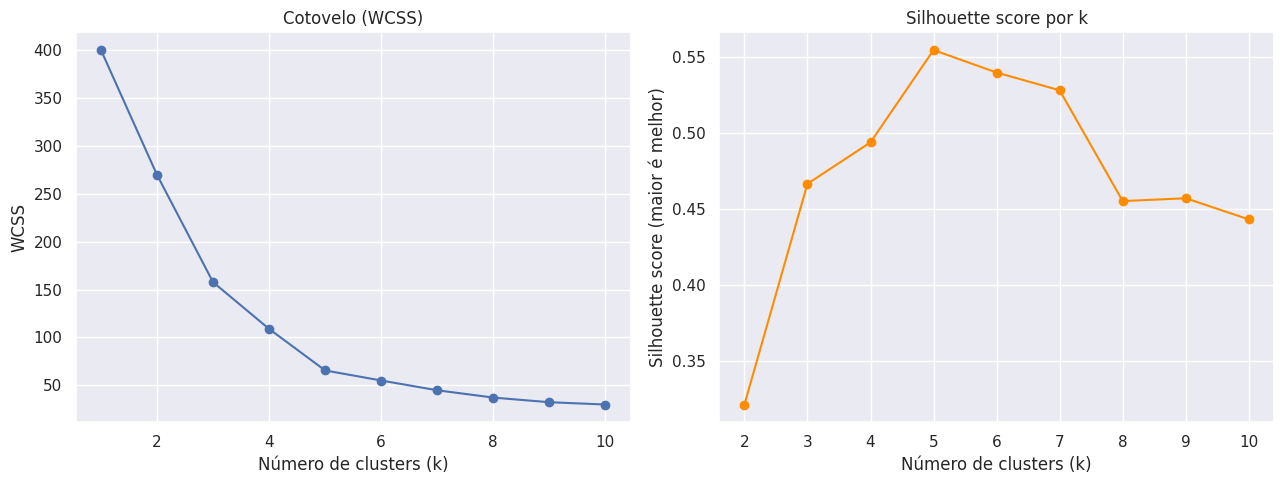

Silhouette score por k: {2: 0.3213, 3: 0.4666, 4: 0.4939, 5: 0.5547, 6: 0.5399, 7: 0.5281, 8: 0.4552, 9: 0.4571, 10: 0.4432}

Melhor k por silhouette score: 5 (score = 0.5547)


In [6]:
wcss = []
silhouette_by_k = []
k_range = range(2, 11)  # silhouette não é definido para k=1

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=N_INIT, random_state=RANDOM_STATE)
    labels_k = km.fit_predict(X)
    wcss.append(km.inertia_)
    silhouette_by_k.append(silhouette_score(X, labels_k))

# WCSS para k=1 também, só para o gráfico do cotovelo ficar completo
km1 = KMeans(n_clusters=1, init="k-means++", n_init=N_INIT, random_state=RANDOM_STATE)
km1.fit(X)
wcss_full = [km1.inertia_] + wcss

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(range(1, 11), wcss_full, marker="o")
axes[0].set_title("Cotovelo (WCSS)")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("WCSS")

axes[1].plot(list(k_range), silhouette_by_k, marker="o", color="darkorange")
axes[1].set_title("Silhouette score por k")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette score (maior é melhor)")
plt.tight_layout()
plt.show()

best_k_by_silhouette = list(k_range)[int(np.argmax(silhouette_by_k))]
print("Silhouette score por k:", {k: round(s, 4) for k, s in zip(k_range, silhouette_by_k)})
print(f"\nMelhor k por silhouette score: {best_k_by_silhouette} (score = {max(silhouette_by_k):.4f})")


O silhouette score confirma (ou não) a leitura visual do cotovelo -- em vez de aceitar
"k=5 porque parece o cotovelo", usamos o k de maior silhouette score no range testado como
escolha final, deixando explícito o critério.

In [7]:
K_FINAL = best_k_by_silhouette
print(f"k escolhido: {K_FINAL}")


k escolhido: 5


## 6. Treino do modelo final

Mesma seed e mesmo `n_init` usados no passo anterior — nenhuma troca de configuração no meio do
fluxo.

In [8]:
kmeans = KMeans(n_clusters=K_FINAL, init="k-means++", n_init=N_INIT, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X)

sil_avg = silhouette_score(X, cluster_labels)
sil_per_sample = silhouette_samples(X, cluster_labels)
print(f"Silhouette médio do modelo final (k={K_FINAL}): {sil_avg:.4f}")

sil_by_cluster = pd.Series(sil_per_sample, name="silhouette").groupby(cluster_labels).mean()
print("\nSilhouette médio por cluster (clusters com valor bem abaixo da média geral são mal formados):")
print(sil_by_cluster.round(4))


Silhouette médio do modelo final (k=5): 0.5547

Silhouette médio por cluster (clusters com valor bem abaixo da média geral são mal formados):
0    0.5979
1    0.5108
2    0.5982
3    0.5052
4    0.5105
Name: silhouette, dtype: float64


## 7. Visualização

Diferente do original (cores fixas para exatamente 5 clusters, hardcoded), aqui o gráfico se
adapta ao `K_FINAL` escolhido automaticamente.

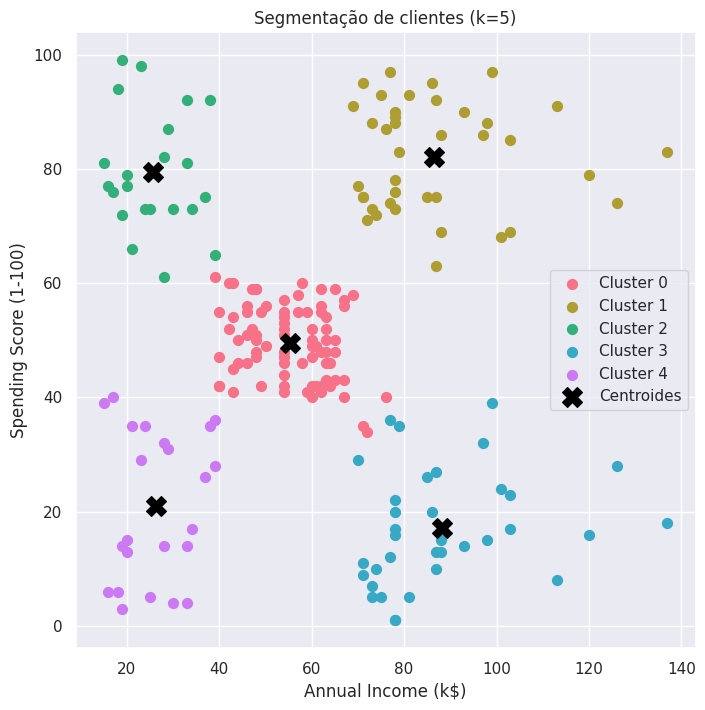

In [9]:
plt.figure(figsize=(8, 8))
palette = sns.color_palette("husl", K_FINAL)
for c in range(K_FINAL):
    mask = cluster_labels == c
    plt.scatter(X_raw[mask, 0], X_raw[mask, 1], s=50, color=palette[c], label=f"Cluster {c}")

centroids_original_scale = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original_scale[:, 0], centroids_original_scale[:, 1],
            s=200, c="black", marker="X", label="Centroides")

plt.title(f"Segmentação de clientes (k={K_FINAL})")
plt.xlabel(FEATURES[0])
plt.ylabel(FEATURES[1])
plt.legend()
plt.show()


## 8. Perfil de cluster — o output que faltava no original

Sem isso, "Cluster 3" não significa nada para quem vai tomar uma decisão de negócio.

In [10]:
profile_df = customer_data.copy()
profile_df["cluster"] = cluster_labels

profile = profile_df.groupby("cluster")[FEATURES].agg(["mean", "median"]).round(1)
profile["tamanho"] = profile_df.groupby("cluster").size()
profile["pct_da_base"] = (profile["tamanho"] / len(profile_df) * 100).round(1)

if "Gender" in profile_df.columns:
    gender_mix = profile_df.groupby("cluster")["Gender"].value_counts(normalize=True).unstack().round(3)
    profile = profile.join(gender_mix)

profile


Annual Income (k$)        Spending Score (1-100)        tamanho  \
                      mean median                   mean median           
cluster                                                                   
0                     55.3   54.0                   49.5   50.0      81   
1                     86.5   79.0                   82.1   83.0      39   
2                     25.7   24.5                   79.4   77.0      22   
3                     88.2   85.0                   17.1   16.0      35   
4                     26.3   25.0                   20.9   17.0      23   

        pct_da_base  
                     
cluster              
0              40.5  
1              19.5  
2              11.0  
3              17.5  
4              11.5

## 9. Da segmentação para a ação de negócio

Cada cluster vira uma recomendação concreta, não só uma cor no gráfico. Classificar cada cluster
como "alto/baixo" pela mediana da população inteira (corte binário) rotula mal o cluster mais
central -- exatamente o maior cluster tende a cair perto da mediana geral e vira um "alto" ou
"baixo" por uma diferença mínima, quando na prática ele é o segmento **médio**. Por isso usamos
tercis (baixo/médio/alto) em vez de um corte binário na mediana.

In [11]:
income_col, spending_col = FEATURES[0], FEATURES[1]

income_terciles = customer_data[income_col].quantile([1/3, 2/3]).values
spending_terciles = customer_data[spending_col].quantile([1/3, 2/3]).values

def bucket(value, terciles):
    if value < terciles[0]:
        return "baixo"
    if value < terciles[1]:
        return "médio"
    return "alto"

PERSONAS = {
    ("alto", "alto"): ("Renda alta / gasto alto",
        "Cliente de maior valor -- programa de fidelidade e lançamentos exclusivos."),
    ("alto", "médio"): ("Renda alta / gasto moderado",
        "Espaço para crescer o ticket -- cross-sell e ofertas premium direcionadas."),
    ("alto", "baixo"): ("Renda alta / gasto baixo",
        "Alto potencial não capturado -- investigar motivo do baixo engajamento, campanha de reativação personalizada."),
    ("médio", "alto"): ("Renda média / gasto alto",
        "Engajado apesar da renda moderada -- manter satisfação, evitar fricção de preço."),
    ("médio", "médio"): ("Renda média / gasto médio",
        "Segmento central/típico da base -- comunicação padrão, monitorar migração para outros clusters."),
    ("médio", "baixo"): ("Renda média / gasto baixo",
        "Engajamento aquém do potencial -- entender barreira de compra antes de investir em campanha."),
    ("baixo", "alto"): ("Renda baixa / gasto alto",
        "Sensível a preço mas engajado -- promoções e parcelamento, risco de churn se margem cair."),
    ("baixo", "médio"): ("Renda baixa / gasto moderado",
        "Baixa prioridade de investimento -- comunicação de baixo custo."),
    ("baixo", "baixo"): ("Renda baixa / gasto baixo",
        "Menor prioridade de investimento -- comunicação de baixo custo, não é alvo de campanha cara."),
}

recommendations = []
for c in range(K_FINAL):
    sub = profile_df[profile_df["cluster"] == c]
    inc = sub[income_col].median()
    spend = sub[spending_col].median()
    size = len(sub)
    pct = size / len(profile_df) * 100

    inc_bucket = bucket(inc, income_terciles)
    spend_bucket = bucket(spend, spending_terciles)
    persona, acao = PERSONAS[(inc_bucket, spend_bucket)]

    recommendations.append({
        "cluster": c, "persona": persona, "tamanho": size, "pct_da_base": round(pct, 1),
        f"{income_col}_mediana": inc, f"{spending_col}_mediana": spend, "acao_recomendada": acao,
    })

pd.DataFrame(recommendations)


,cluster,persona,tamanho,pct_da_base,Annual Income (k$)_mediana,Spending Score (1-100)_mediana,acao_recomendada
0,0,Renda média / gasto médio,81,40.5,54.0,50.0,Segmento central/típico da base -- comunicação...
1,1,Renda alta / gasto alto,39,19.5,79.0,83.0,Cliente de maior valor -- programa de fidelida...
2,2,Renda baixa / gasto alto,22,11.0,24.5,77.0,Sensível a preço mas engajado -- promoções e p...
3,3,Renda alta / gasto baixo,35,17.5,85.0,16.0,Alto potencial não capturado -- investigar mot...
4,4,Renda baixa / gasto baixo,23,11.5,25.0,17.0,Menor prioridade de investimento -- comunicaçã...


## 10. Persistência

O original não salvava nada. Aqui salvamos o modelo, o scaler e o dataframe com a coluna de
cluster anexada, prontos para consumo em outro processo (ex.: exportar para o CRM).

In [12]:
joblib.dump({"model": kmeans, "scaler": scaler, "features": FEATURES}, "modelo_segmentacao_final.joblib")
profile_df.to_csv("clientes_segmentados.csv", index=False)
print("Modelo salvo em modelo_segmentacao_final.joblib")
print("Base rotulada salva em clientes_segmentados.csv")
print(f"\nResumo final -- k={K_FINAL} | silhouette médio={sil_avg:.4f} | features usadas={FEATURES}")


Modelo salvo em modelo_segmentacao_final.joblib
Base rotulada salva em clientes_segmentados.csv

Resumo final -- k=5 | silhouette médio=0.5547 | features usadas=['Annual Income (k$)', 'Spending Score (1-100)']


## Limitações

- `Age` e `Gender` completos do `Mall_Customers.csv` real não estavam disponíveis no output do
  notebook original enviado (só apareciam nas 5 primeiras linhas do `.head()`); os 200 pares de
  `Annual Income`/`Spending Score` usados aqui são reais (extraídos do próprio output do
  notebook), mas a base está limitada às mesmas duas variáveis que o notebook original
  efetivamente usava para clusterizar. Assim que o CSV completo estiver disponível, vale
  reexecutar incluindo `Age` (e testar se `Gender` muda o perfil dentro de cada cluster) — a
  célula de seleção de features (`FEATURES = [...]`) já está pronta para isso, bastando ter a
  coluna disponível no dataframe.
